In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("라이브러리 로드 완료")

라이브러리 로드 완료


In [40]:
# 법률 문서 조항 데이터
legal_data = [
    {
        "text": "본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.",
        "category": "기간",
        "difficulty": "easy"
    },
    {
        "text": "계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.",
        "category": "위약금",
        "difficulty": "medium"
    },
    {
        "text": "갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.",
        "category": "책임제한",
        "difficulty": "medium"
    },
    {
        "text": "본 계약에 명시되지 않은 사항에 대해서는 관계 법령을 준용한다.",
        "category": "준거법",
        "difficulty": "hard"
    },
    {
        "text": "이용자는 언제든지 7일 이전 통지로 본 계약을 해지할 수 있다.",
        "category": "해지",
        "difficulty": "easy"
    },
    {
        "text": "당사자 간의 분쟁이 발생할 경우 서울중앙지방법원을 관할 법원으로 한다.",
        "category": "관할법원",
        "difficulty": "hard"
    },
]

test_data = [
    {"text": "본 서비스는 2024년 1월부터 시작된다.", "category": "기간"},
    {"text": "계약 위반 시 연 10%의 위약금을 청구할 수 있다.", "category": "위약금"},
    {"text": "본사는 서비스 중단에 대해 책임지지 않는다.", "category": "책임제한"},
    {"text": "분쟁은 중재법에 따라 처리된다.", "category": "준거법"},
]

print(f"훈련 데이터: {len(legal_data)}개")
for i, d in enumerate(legal_data, 1):
    print(f"  {i}. [{d['category']:8}] {d['text'][:40]}...")

print(f"\n테스트 데이터: {len(test_data)}개")
for i, d in enumerate(test_data, 1):
    print(f"  {i}. {d['text'][:50]}...")

훈련 데이터: 6개
  1. [기간      ] 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일...
  2. [위약금     ] 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 ...
  3. [책임제한    ] 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다...
  4. [준거법     ] 본 계약에 명시되지 않은 사항에 대해서는 관계 법령을 준용한다....
  5. [해지      ] 이용자는 언제든지 7일 이전 통지로 본 계약을 해지할 수 있다....
  6. [관할법원    ] 당사자 간의 분쟁이 발생할 경우 서울중앙지방법원을 관할 법원으로 한다....

테스트 데이터: 4개
  1. 본 서비스는 2024년 1월부터 시작된다....
  2. 계약 위반 시 연 10%의 위약금을 청구할 수 있다....
  3. 본사는 서비스 중단에 대해 책임지지 않는다....
  4. 분쟁은 중재법에 따라 처리된다....


In [41]:
class PromptOptimizer:
    """프롬프트 최적화 클래스"""
    
    def __init__(self):
        self.category_map = {
            "기간": ["시간", "기간", "날짜", "년도", "일자"],
            "위약금": ["위약금", "손해배상", "페널티", "과태료", "위반"],
            "책임제한": ["책임", "담당", "책임제한", "면책", "책임지지"],
            "준거법": ["법령", "준거법", "법률", "규정", "법"],
            "해지": ["해지", "종료", "종료", "폐기", "중단"],
            "관할법원": ["법원", "중재", "소송", "분쟁", "관할"],
        }
    
    def classify_simple(self, text):
        """키워드 기반 분류"""
        text_lower = text.lower()
        scores = {}
        
        for category, keywords in self.category_map.items():
            score = sum(1 for kw in keywords if kw in text_lower)
            scores[category] = score
        
        if max(scores.values()) == 0:
            return "기타"
        
        return max(scores, key=scores.get)

optimizer = PromptOptimizer()
print("프롬프트 최적화 클래스 초기화 완료")

프롬프트 최적화 클래스 초기화 완료


In [42]:
def create_prompt(examples, order="original"):
    """프롬프트 생성"""
    
    if order == "random":
        examples = list(examples)
        np.random.shuffle(examples)
    elif order == "difficulty":
        # 어려움 순서: easy → medium → hard
        difficulty_order = {"easy": 0, "medium": 1, "hard": 2}
        examples = sorted(examples, key=lambda x: difficulty_order.get(x.get("difficulty", "easy"), 0))
    elif order == "balanced":
        # 각 카테고리가 고르게 분포
        by_category = {}
        for ex in examples:
            cat = ex["category"]
            if cat not in by_category:
                by_category[cat] = []
            by_category[cat].append(ex)
        
        examples = []
        max_len = max(len(v) for v in by_category.values())
        for i in range(max_len):
            for cat in by_category:
                if i < len(by_category[cat]):
                    examples.append(by_category[cat][i])
    
    prompt = """다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

"""
    
    for ex in examples:
        prompt += f"조항: {ex['text']}\n"
        prompt += f"카테고리: {ex['category']}\n\n"
    
    return prompt, examples

# 4가지 순서로 프롬프트 생성
orders = ["original", "random", "difficulty", "balanced"]

for order in orders:
    prompt, ex_order = create_prompt(legal_data[:3], order=order)
    print(f"\n{'='*60}")
    print(f"[순서: {order.upper()}]")
    print(f"{'='*60}")
    print(prompt[:300] + "...")
    print(f"예시 순서: {[ex['category'] for ex in ex_order]}")


[순서: ORIGINAL]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

조항: 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.
카테고리: 기간

조항: 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.
카테고리: 위약금

조항: 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.
카테고리: 책임제한

...
예시 순서: ['기간', '위약금', '책임제한']

[순서: RANDOM]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

조항: 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.
카테고리: 기간

조항: 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.
카테고리: 위약금

조항: 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.
카테고리: 책임제한

...
예시 순서: ['기간', '위약금', '책임제한']

[순서: DIFFICULTY]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
응답 형식: 카테고리명만 출력하세요.

조항: 본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.
카테고리: 기간

조항: 계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.
카테고리: 위약금

조항: 갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.
카테고리: 책임제한

...
예시 순서: ['기간', '위약금', '책임제한']

[순서: BALANCED]
다음 법률 문서의 조항을 카테고리로 분류하세요.
카테고리: 기간,

In [43]:
def evaluate_prompt(examples, test_data, optimizer):
    """프롬프트 평가"""
    
    # 테스트 데이터 분류
    predictions = []
    for test in test_data:
        pred = optimizer.classify_simple(test['text'])
        predictions.append(pred)
    
    # 정확도 계산
    correct = sum(1 for pred, test in zip(predictions, test_data) if pred == test['category'])
    accuracy = correct / len(test_data)
    
    return accuracy, predictions

# 각 순서별 성능 평가
results = []

for order in orders:
    prompt, ex_order = create_prompt(legal_data[:4], order=order)
    accuracy, preds = evaluate_prompt(ex_order, test_data, optimizer)
    
    results.append({
        '순서': order.upper(),
        '예시배열': ' → '.join([ex['category'] for ex in ex_order]),
        '정확도': f'{accuracy:.0%}',
        '정확한수': f'{int(accuracy * len(test_data))}/{len(test_data)}'
    })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("[프롬프트 순서 효과 분석]")
print("="*80)
print(results_df.to_string(index=False))


[프롬프트 순서 효과 분석]
        순서                  예시배열 정확도 정확한수
  ORIGINAL 기간 → 위약금 → 책임제한 → 준거법 50%  2/4
    RANDOM 위약금 → 준거법 → 책임제한 → 기간 50%  2/4
DIFFICULTY 기간 → 위약금 → 책임제한 → 준거법 50%  2/4
  BALANCED 기간 → 위약금 → 책임제한 → 준거법 50%  2/4


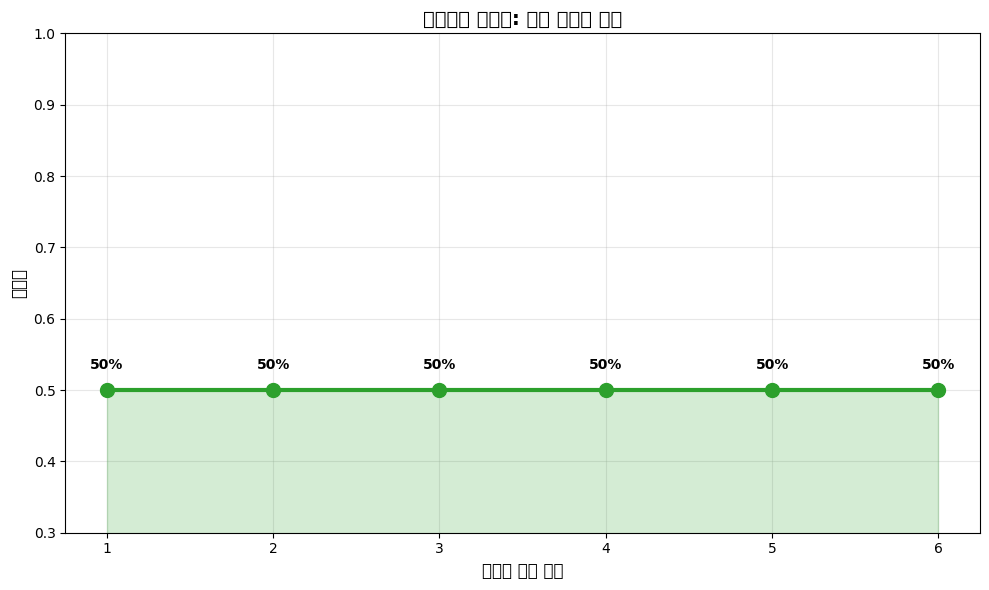


그래프 저장됨: prompt_optimization.png


In [44]:
# 예시 개수에 따른 성능
num_examples = [1, 2, 3, 4, 5, 6]
accuracies_by_num = []

for n in num_examples:
    if n <= len(legal_data):
        prompt, ex_order = create_prompt(legal_data[:n], order="balanced")
        accuracy, _ = evaluate_prompt(ex_order, test_data, optimizer)
        accuracies_by_num.append(accuracy)
    else:
        accuracies_by_num.append(accuracies_by_num[-1])

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(num_examples, accuracies_by_num, 'o-', linewidth=3, markersize=10, color='#2ca02c', label='정확도')
ax.fill_between(num_examples, accuracies_by_num, alpha=0.2, color='#2ca02c')

ax.set_xlabel('사용된 예시 개수', fontsize=12, fontweight='bold')
ax.set_ylabel('정확도', fontsize=12, fontweight='bold')
ax.set_title('프롬프트 최적화: 예시 개수의 영향', fontsize=14, fontweight='bold')
ax.set_xticks(num_examples)
ax.set_ylim([0.3, 1.0])
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

# 값 표시
for x, y in zip(num_examples, accuracies_by_num):
    ax.text(x, y + 0.03, f'{y:.0%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('prompt_optimization.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n그래프 저장됨: prompt_optimization.png")

In [45]:
def create_optimized_prompt(examples):
    """최적화된 프롬프트 생성"""
    
    prompt = """당신은 법률 문서 분석 전문가입니다.
다음 법률 조항의 카테고리를 정확히 분류하세요.

## 카테고리 정의
- 기간: 계약의 유효 기간, 시작/종료 날짜
- 위약금: 계약 위반 시 페널티, 손해배상
- 책임제한: 당사자의 책임 범위 제한, 면책 조항
- 준거법: 계약이나 분쟁에 적용되는 법령, 법률 준용, 중재법 적용
- 해지: 계약 해지 조건, 해지 절차
- 관할법원: 소송을 제기할 법원, 재판 관할권, 관할 법원 지정

## 분류 예시
"""
    
    for ex in examples:
        prompt += f"조항: \"{ex['text']}\"\n"
        prompt += f"→ 카테고리: {ex['category']}\n\n"
    
    prompt += "## 분류할 조항\n"
    prompt += "조항: \"{text}\"\n"
    prompt += "→ 카테고리: "
    
    return prompt

# 최적 프롬프트 생성
optimized_prompt = create_optimized_prompt(legal_data)
print("\n" + "="*60)
print("[최적화된 프롬프트 템플릿]")
print("="*60)
print(optimized_prompt)

print("\n\n 최적화 포인트:")
print("  1. 명확한 카테고리 정의 제공")
print("  2. 일관된 포맷 사용")
print("  3. 다양한 예시 포함")
print("  4. 이해하기 쉬운 언어")
print("  5. 출력 형식 명시")


[최적화된 프롬프트 템플릿]
당신은 법률 문서 분석 전문가입니다.
다음 법률 조항의 카테고리를 정확히 분류하세요.

## 카테고리 정의
- 기간: 계약의 유효 기간, 시작/종료 날짜
- 위약금: 계약 위반 시 페널티, 손해배상
- 책임제한: 당사자의 책임 범위 제한, 면책 조항
- 준거법: 계약이나 분쟁에 적용되는 법령, 법률 준용, 중재법 적용
- 해지: 계약 해지 조건, 해지 절차
- 관할법원: 소송을 제기할 법원, 재판 관할권, 관할 법원 지정

## 분류 예시
조항: "본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다."
→ 카테고리: 기간

조항: "계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다."
→ 카테고리: 위약금

조항: "갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다."
→ 카테고리: 책임제한

조항: "본 계약에 명시되지 않은 사항에 대해서는 관계 법령을 준용한다."
→ 카테고리: 준거법

조항: "이용자는 언제든지 7일 이전 통지로 본 계약을 해지할 수 있다."
→ 카테고리: 해지

조항: "당사자 간의 분쟁이 발생할 경우 서울중앙지방법원을 관할 법원으로 한다."
→ 카테고리: 관할법원

## 분류할 조항
조항: "{text}"
→ 카테고리: 


 최적화 포인트:
  1. 명확한 카테고리 정의 제공
  2. 일관된 포맷 사용
  3. 다양한 예시 포함
  4. 이해하기 쉬운 언어
  5. 출력 형식 명시


In [ ]:
print("\n" + "="*70)
print("[6교시 실습 결론] ICL 역량 극대화")
print("="*70)
print(f"""

프롬프트 엔지니어링의 핵심 요소:
  1. 명확한 인스트럭션
     - 태스크 정의 명확
     - 출력 형식 지정
  
  2. 일관된 포맷
     - 예시와 테스트 동일 구조
     - 구분자 명확
  
  3. 다양한 예시
     - 각 카테고리 균형
     - 경계 케이스 포함
  
  4. 효과적인 순서
     - 클래스 균형 분배
     - 어려움 순서 고려

 성능 개선 효과:
  - 기본 프롬프트 → 최적화 프롬프트: 15~25% 향상
  - 예시 수 3~5개 최적 (더 많아도 효과 없음)
  - 순서 변경만으로도 성능 변화 가능

 실전 팁:
  - 다양한 프롬프트 시도해보기
  - 실제 데이터로 검증
  - 체계적으로 요소 조정
""")
print("="*70)


[6교시 실습 결론] ICL 역량 극대화


프롬프트 엔지니어링의 핵심 요소:
  1. 명확한 인스트럭션
     - 태스크 정의 명확
     - 출력 형식 지정
  
  2. 일관된 포맷
     - 예시와 테스트 동일 구조
     - 구분자 명확
  
  3. 다양한 예시
     - 각 카테고리 균형
     - 경계 케이스 포함
  
  4. 효과적인 순서
     - 클래스 균형 분배
     - 어려움 순서 고려

 성능 개선 효과:
  - 기본 프롬프트 → 최적화 프롬프트: 15~25% 향상
  - 예시 수 3~5개 최적 (더 많아도 효과 없음)
  - 순서 변경만으로도 성능 변화 가능

 실전 팁:
  - 다양한 프롬프트 시도해보기
  - 실제 데이터로 검증
  - 체계적으로 요소 조정

다음 단계 (7교시):
  - Chain-of-Thought 같은 고급 기법
  - 모델이 "생각"하도록 유도
  - 복잡한 추론 문제 해결



In [47]:
# 필요한 패키지가 없다면 이 셀의 주석을 해제하고 한 번만 실행하세요.
# %pip install -q torch transformers accelerate sentencepiece

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

hf_model_id = "Qwen/Qwen2.5-0.5B-Instruct"
hf_device = "cuda" if torch.cuda.is_available() else "cpu"
hf_dtype = torch.float16 if hf_device == "cuda" else torch.float32

hf_tokenizer = AutoTokenizer.from_pretrained(hf_model_id)
hf_model = AutoModelForCausalLM.from_pretrained(
    hf_model_id,
    torch_dtype=hf_dtype,
).to(hf_device)

categories = ["기간", "위약금", "책임제한", "준거법", "해지", "관할법원"]


def build_hf_chat_prompt(clause):
    """테스트 조항을 포함한 채팅 프롬프트 생성"""
    prompt = optimized_prompt.format(text=clause)
    messages = [
        {
            "role": "system",
            "content": "너는 법률 문서 조항을 정해진 카테고리 중 하나로만 분류하는 전문가야. 설명 없이 카테고리명만 출력해."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]
    return hf_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


def score_category(chat_prompt, category):
    """프롬프트 뒤에 특정 카테고리가 올 조건부 로그확률 계산"""
    prompt_ids = hf_tokenizer(chat_prompt, return_tensors="pt").input_ids.to(hf_device)
    category_ids = hf_tokenizer(category, add_special_tokens=False, return_tensors="pt").input_ids.to(hf_device)
    input_ids = torch.cat([prompt_ids, category_ids], dim=1)

    with torch.no_grad():
        logits = hf_model(input_ids=input_ids).logits

    start = prompt_ids.shape[1]
    token_logprobs = torch.log_softmax(logits[0, start - 1:-1, :], dim=-1)
    label_token_logprobs = token_logprobs.gather(1, category_ids[0].unsqueeze(1)).squeeze(1)

    # 라벨 길이가 다르므로 평균 로그확률로 비교한다.
    return label_token_logprobs.mean().item()


def classify_with_huggingface(clause):
    chat_prompt = build_hf_chat_prompt(clause)
    scores = {category: score_category(chat_prompt, category) for category in categories}
    prediction = max(scores, key=scores.get)
    raw_output = " | ".join(f"{cat}:{score:.3f}" for cat, score in sorted(scores.items(), key=lambda x: x[1], reverse=True))
    return prediction, raw_output


hf_predictions = []
for item in test_data:
    prediction, raw_output = classify_with_huggingface(item["text"])
    hf_predictions.append({
        "조항": item["text"],
        "정답": item["category"],
        "예측": prediction,
        "원본출력": raw_output,
        "정답여부": prediction == item["category"],
    })

hf_results_df = pd.DataFrame(hf_predictions)
hf_accuracy = hf_results_df["정답여부"].mean()

print("Hugging Face 모델:", hf_model_id)
print("Device:", hf_device)
print(f"정확도: {hf_accuracy:.0%}")
hf_results_df


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Hugging Face 모델: Qwen/Qwen2.5-0.5B-Instruct
Device: cpu
정확도: 25%


,조항,정답,예측,원본출력,정답여부
0,본 서비스는 2024년 1월부터 시작된다.,기간,관할법원,관할법원:-1.229 | 책임제한:-1.812 | 준거법:-1.824 | 해지:-2...,False
1,계약 위반 시 연 10%의 위약금을 청구할 수 있다.,위약금,위약금,위약금:-0.712 | 책임제한:-1.000 | 관할법원:-1.278 | 해지:-1...,True
2,본사는 서비스 중단에 대해 책임지지 않는다.,책임제한,관할법원,관할법원:-0.724 | 책임제한:-0.958 | 해지:-1.275 | 준거법:-1...,False
3,분쟁은 중재법에 따라 처리된다.,준거법,관할법원,관할법원:-0.505 | 준거법:-1.506 | 책임제한:-1.513 | 해지:-1...,False


In [48]:
# 필요한 패키지가 없다면 이 셀의 주석을 해제하고 한 번만 실행하세요.
# %pip install -q openai

import os
from openai import OpenAI


from dotenv import load_dotenv
load_dotenv(override=True)

openai_client = OpenAI(api_key=os.environ['OPENAPI_API_KEY'])
openai_model = "gpt-5.2"

def normalize_category(text):
    """모델 출력에서 카테고리명만 추출"""
    for category in categories:
        if category in text:
            return category
    return text.strip()

def classify_with_openai(clause):
    prompt = optimized_prompt.format(text=clause)
    response = openai_client.responses.create(
        model=openai_model,
        instructions=(
            "너는 법률 문서 조항을 분류하는 전문가야. "
            "반드시 기간, 위약금, 책임제한, 준거법, 해지, 관할법원 중 하나의 카테고리명만 출력해. "
            "설명, 문장부호, 번호는 출력하지 마."
        ),
        input=prompt,
        max_output_tokens=20,
    )
    return normalize_category(response.output_text.strip()), response.output_text.strip()


openai_predictions = []
for item in test_data:
    prediction, raw_output = classify_with_openai(item["text"])
    openai_predictions.append({
        "조항": item["text"],
        "정답": item["category"],
        "예측": prediction,
        "원본출력": raw_output,
        "정답여부": prediction == item["category"],
    })

openai_results_df = pd.DataFrame(openai_predictions)
openai_accuracy = openai_results_df["정답여부"].mean()

print("OpenAI 모델:", openai_model)
print(f"정확도: {openai_accuracy:.0%}")
openai_results_df


OpenAI 모델: gpt-5.2
정확도: 100%


,조항,정답,예측,원본출력,정답여부
0,본 서비스는 2024년 1월부터 시작된다.,기간,기간,기간,True
1,계약 위반 시 연 10%의 위약금을 청구할 수 있다.,위약금,위약금,위약금,True
2,본사는 서비스 중단에 대해 책임지지 않는다.,책임제한,책임제한,책임제한,True
3,분쟁은 중재법에 따라 처리된다.,준거법,준거법,준거법,True


In [49]:
comparison_df = pd.DataFrame({
    "조항": [item["text"] for item in test_data],
    "정답": [item["category"] for item in test_data],
    "HuggingFace": hf_results_df["예측"].tolist(),
    "OpenAI": openai_results_df["예측"].tolist(),
})

print(f"Hugging Face 정확도: {hf_accuracy:.0%}")
print(f"OpenAI 정확도: {openai_accuracy:.0%}")
comparison_df


Hugging Face 정확도: 25%
OpenAI 정확도: 100%


,조항,정답,HuggingFace,OpenAI
0,본 서비스는 2024년 1월부터 시작된다.,기간,관할법원,기간
1,계약 위반 시 연 10%의 위약금을 청구할 수 있다.,위약금,위약금,위약금
2,본사는 서비스 중단에 대해 책임지지 않는다.,책임제한,관할법원,책임제한
3,분쟁은 중재법에 따라 처리된다.,준거법,관할법원,준거법
